# Chapter 2, Example 4: Ising Chains, Loops, and Frustration

The Ising model is a compact laboratory for nearly every theme of this book. It combines local factors, a partition function, inference, optimization, sampling, learning, and graph topology.

This notebook compares:

- a six-spin chain, which is a tree;
- a ferromagnetic triangle, whose interactions can all be satisfied;
- an antiferromagnetic triangle, which is frustrated because an odd cycle cannot satisfy all pairwise preferences simultaneously.

All calculations use exact enumeration. The same examples will later be revisited with belief propagation, Monte Carlo sampling, loop corrections, tensor networks, and parameter learning.

## 1. Pairwise Ising model

For spins $s_i\in\{-1,+1\}$ on a graph $G=(V,E)$, define

$$
p_{\beta}(\boldsymbol{s})
=
\frac{1}{Z(\beta)}
\exp\left(
\beta\left(
\sum_{(i,j)\in E}J_{ij}s_is_j
+
\sum_{i\in V}h_is_i
\right)
\right).
$$

Positive $J_{ij}$ favors alignment and negative $J_{ij}$ favors anti-alignment. The inverse temperature $\beta$ controls concentration: at small $\beta$ the distribution is diffuse, while at large $\beta$ it concentrates near energy-minimizing configurations.

In [1]:
from pathlib import Path
from itertools import product

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

# Publication-oriented typography shared by all Chapter 2 figures.
plt.rcParams.update({
    "font.size": 15,
    "axes.titlesize": 18,
    "axes.labelsize": 16,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 13,
    "figure.titlesize": 19,
    "lines.linewidth": 2.0,
})

CWD = Path.cwd()
if CWD.name == "ch02":
    NOTEBOOK_DIR = CWD
elif (CWD / "notebooks" / "ch02").exists():
    NOTEBOOK_DIR = CWD / "notebooks" / "ch02"
else:
    NOTEBOOK_DIR = CWD
FIG_DIR = NOTEBOOK_DIR / "figs"
FIG_DIR.mkdir(parents=True, exist_ok=True)


def save_figure(fig, stem):
    for suffix, kwargs in [("pdf", {}), ("png", {"dpi": 220})]:
        path = FIG_DIR / f"{stem}.{suffix}"
        fig.savefig(path, bbox_inches="tight", **kwargs)
        print(f"Saved: {path}")


def enumerate_ising(n, edges, couplings, fields=None, beta=1.0):
    fields = np.zeros(n) if fields is None else np.asarray(fields, dtype=float)
    states = np.array(list(product([-1, 1], repeat=n)), dtype=int)
    scores = np.zeros(len(states))
    for k, state in enumerate(states):
        pair_score = sum(couplings[e] * state[e[0]] * state[e[1]] for e in edges)
        scores[k] = pair_score + fields @ state
    shifted = beta * scores - np.max(beta * scores)
    unnormalized = np.exp(shifted)
    probabilities = unnormalized / unnormalized.sum()
    logZ = np.max(beta * scores) + np.log(unnormalized.sum())
    return states, probabilities, scores, logZ


def exact_observables(states, probabilities, edges):
    mean = probabilities @ states
    correlation = (states.T * probabilities) @ states
    edge_correlation = np.mean([
        np.sum(probabilities * states[:, i] * states[:, j]) for i, j in edges
    ])
    return mean, correlation, edge_correlation


def spin_label(state):
    return "".join("+" if s == 1 else "−" for s in state)

## 2. Tree and loop topologies

The chain contains no cycles. Removing any edge separates it into two components. The triangle contains one elementary loop. For antiferromagnetic interactions on the triangle, every edge prefers opposite endpoint spins, but three pairwise inequalities cannot all hold around an odd cycle.

Saved: figs/ch02_04_chain_and_triangle_topologies.pdf
Saved: figs/ch02_04_chain_and_triangle_topologies.png


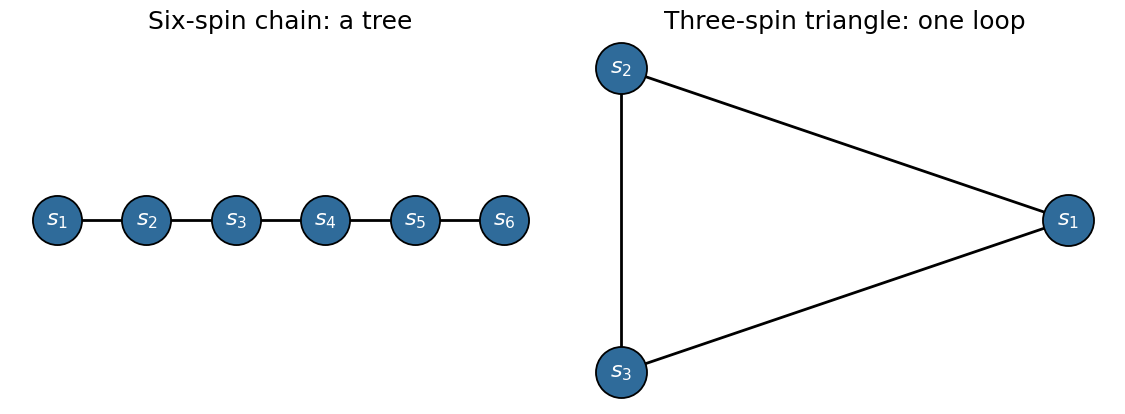

In [2]:
chain_edges = [(i, i + 1) for i in range(5)]
triangle_edges = [(0, 1), (1, 2), (2, 0)]

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.4))
chain_graph = nx.Graph(chain_edges)
chain_pos = {i: (i, 0) for i in range(6)}
nx.draw_networkx_edges(chain_graph, chain_pos, width=2.0, ax=axes[0])
nx.draw_networkx_nodes(chain_graph, chain_pos, node_size=1250, node_color="#2F6B9A", edgecolors="black", linewidths=1.3, ax=axes[0])
nx.draw_networkx_labels(chain_graph, chain_pos, labels={i: rf"$s_{{{i+1}}}$" for i in range(6)}, font_size=16, font_color="white", ax=axes[0])
axes[0].set_title("Six-spin chain: a tree")
axes[0].axis("off")

triangle_graph = nx.Graph(triangle_edges)
triangle_pos = nx.circular_layout(triangle_graph)
nx.draw_networkx_edges(triangle_graph, triangle_pos, width=2.0, ax=axes[1])
nx.draw_networkx_nodes(triangle_graph, triangle_pos, node_size=1350, node_color="#2F6B9A", edgecolors="black", linewidths=1.3, ax=axes[1])
nx.draw_networkx_labels(triangle_graph, triangle_pos, labels={i: rf"$s_{{{i+1}}}$" for i in range(3)}, font_size=16, font_color="white", ax=axes[1])
axes[1].set_title("Three-spin triangle: one loop")
axes[1].axis("off")
fig.tight_layout()
save_figure(fig, "ch02_04_chain_and_triangle_topologies")
plt.show()

## 3. Temperature response of the chain

We use uniform ferromagnetic couplings $J_{ij}=1$ and a weak field $h_i=0.12$. The field breaks the global spin-flip symmetry, so the mean magnetization is visible.

We track

$$
m(\beta)=\frac{1}{n}\sum_i\mathbb{E}[s_i],
$$

and the average nearest-neighbor correlation

$$
c(\beta)=\frac{1}{|E|}\sum_{(i,j)\in E}\mathbb{E}[s_is_j].
$$

Saved: figs/ch02_04_chain_temperature_response.pdf
Saved: figs/ch02_04_chain_temperature_response.png


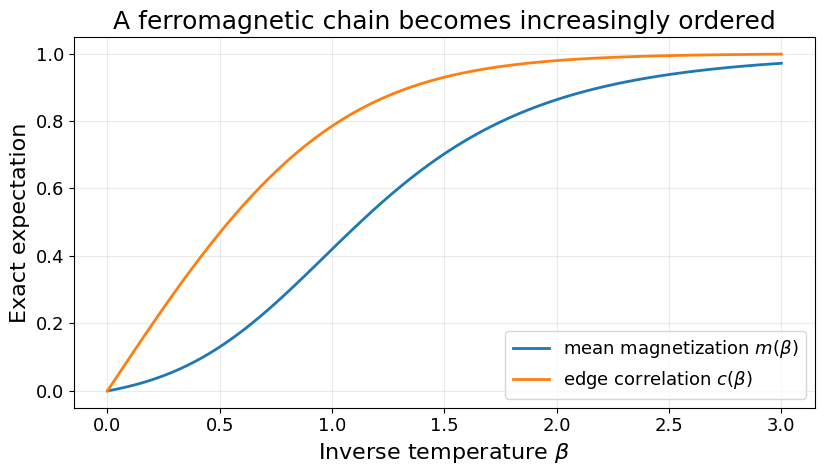

In [3]:
chain_couplings = {edge: 1.0 for edge in chain_edges}
chain_fields = np.full(6, 0.12)
betas = np.linspace(0.0, 3.0, 121)
magnetization = []
edge_corr = []
log_partition = []
for beta in betas:
    states, probs, scores, logZ = enumerate_ising(
        6, chain_edges, chain_couplings, chain_fields, beta
    )
    mean, correlation, corr = exact_observables(states, probs, chain_edges)
    magnetization.append(mean.mean())
    edge_corr.append(corr)
    log_partition.append(logZ)

fig, ax = plt.subplots(figsize=(8.5, 5))
ax.plot(betas, magnetization, label=r"mean magnetization $m(\beta)$")
ax.plot(betas, edge_corr, label=r"edge correlation $c(\beta)$")
ax.set_xlabel(r"Inverse temperature $\beta$")
ax.set_ylabel("Exact expectation")
ax.set_title("A ferromagnetic chain becomes increasingly ordered")
ax.legend()
ax.grid(alpha=0.25)
fig.tight_layout()
save_figure(fig, "ch02_04_chain_temperature_response")
plt.show()

## 4. Ferromagnetic and antiferromagnetic triangles

For the ferromagnetic triangle, the two fully aligned configurations satisfy all three edges.

For the antiferromagnetic triangle, every edge favors unequal spins. Any configuration must leave at least one edge unsatisfied. The six configurations with one spin different from the other two minimize the energy and share the low-temperature probability mass.

Saved: figs/ch02_04_triangle_configuration_probabilities.pdf


Saved: figs/ch02_04_triangle_configuration_probabilities.png


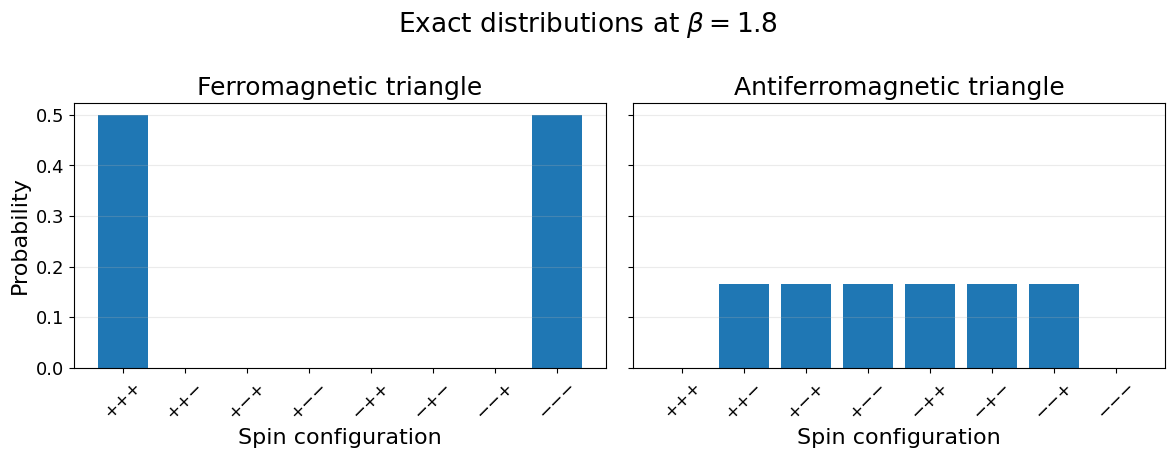

In [4]:
triangle_ferro = {edge: 1.0 for edge in triangle_edges}
triangle_antiferro = {edge: -1.0 for edge in triangle_edges}
triangle_fields = np.zeros(3)
beta_triangle = 1.8

triangle_results = {}
for name, coupling in [("ferromagnetic", triangle_ferro), ("antiferromagnetic", triangle_antiferro)]:
    states, probs, scores, logZ = enumerate_ising(
        3, triangle_edges, coupling, triangle_fields, beta_triangle
    )
    order = np.argsort([spin_label(s) for s in states])
    triangle_results[name] = (states[order], probs[order], scores[order])

fig, axes = plt.subplots(1, 2, figsize=(12, 4.7), sharey=True)
for ax, (name, (states, probs, scores)) in zip(axes, triangle_results.items()):
    labels = [spin_label(s) for s in states]
    ax.bar(labels, probs)
    ax.set_title(f"{name.capitalize()} triangle")
    ax.set_xlabel("Spin configuration")
    ax.tick_params(axis="x", rotation=45)
    ax.grid(axis="y", alpha=0.25)
axes[0].set_ylabel("Probability")
fig.suptitle(rf"Exact distributions at $\beta={beta_triangle}$")
fig.tight_layout()
save_figure(fig, "ch02_04_triangle_configuration_probabilities")
plt.show()

## 5. Counting unsatisfied edges

For an interaction $J_{ij}$, an edge is satisfied when $J_{ij}s_is_j>0$ and unsatisfied when $J_{ij}s_is_j<0$.

The antiferromagnetic triangle can have either one or three unsatisfied edges. It can never have zero unsatisfied edges. As $\beta$ increases, probability concentrates on the six minimally frustrated states with exactly one unsatisfied edge.

Saved: figs/ch02_04_frustration_vs_temperature.pdf


Saved: figs/ch02_04_frustration_vs_temperature.png


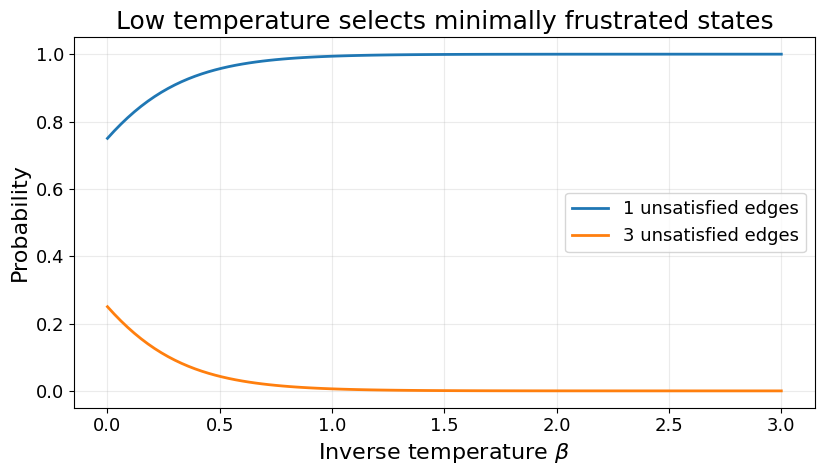

In [5]:
def unsatisfied_count(state, edges, couplings):
    return sum(couplings[e] * state[e[0]] * state[e[1]] < 0 for e in edges)

beta_grid = np.linspace(0, 3, 101)
prob_by_unsatisfied = {0: [], 1: [], 2: [], 3: []}
for beta in beta_grid:
    states, probs, _, _ = enumerate_ising(3, triangle_edges, triangle_antiferro, beta=beta)
    counts = np.array([unsatisfied_count(s, triangle_edges, triangle_antiferro) for s in states])
    for k in prob_by_unsatisfied:
        prob_by_unsatisfied[k].append(probs[counts == k].sum())

fig, ax = plt.subplots(figsize=(8.5, 5))
for k, values in prob_by_unsatisfied.items():
    if np.max(values) > 1e-12:
        ax.plot(beta_grid, values, label=f"{k} unsatisfied edges")
ax.set_xlabel(r"Inverse temperature $\beta$")
ax.set_ylabel("Probability")
ax.set_title("Low temperature selects minimally frustrated states")
ax.legend()
ax.grid(alpha=0.25)
fig.tight_layout()
save_figure(fig, "ch02_04_frustration_vs_temperature")
plt.show()

## 6. Correlation patterns

The correlation matrix

$$
C_{ij}=\mathbb{E}[s_is_j]
$$

summarizes pairwise order. Ferromagnetic correlations are positive. In the frustrated antiferromagnetic triangle, all three pair correlations are negative, but none reaches $-1$ because perfect pairwise anti-alignment is globally impossible.

Saved: figs/ch02_04_triangle_correlation_matrices.pdf


Saved: figs/ch02_04_triangle_correlation_matrices.png


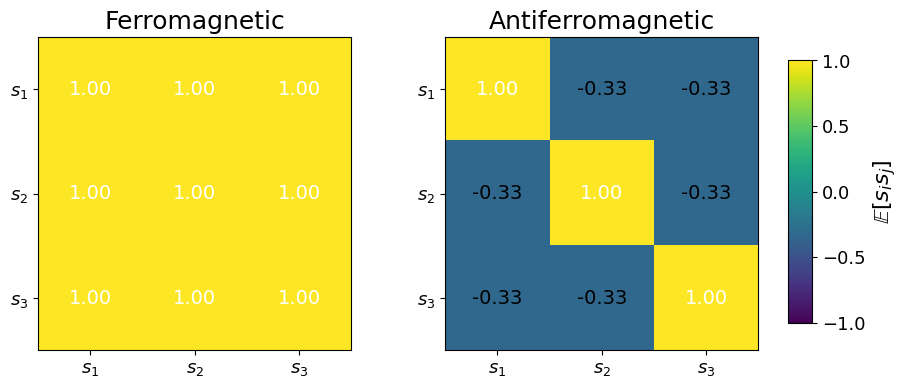

In [6]:
correlation_matrices = {}
for name, coupling in [("Ferromagnetic", triangle_ferro), ("Antiferromagnetic", triangle_antiferro)]:
    states, probs, _, _ = enumerate_ising(3, triangle_edges, coupling, beta=beta_triangle)
    _, corr, _ = exact_observables(states, probs, triangle_edges)
    correlation_matrices[name] = corr

fig, axes = plt.subplots(1, 2, figsize=(9.8, 4.1))
for ax, (name, matrix) in zip(axes, correlation_matrices.items()):
    image = ax.imshow(matrix, vmin=-1, vmax=1)
    for i, j in product(range(3), repeat=2):
        value = matrix[i, j]
        text_color = "white" if abs(value) > 0.52 else "black"
        ax.text(j, i, f"{value:.2f}", ha="center", va="center", color=text_color, fontsize=14)
    ax.set_xticks(range(3), [r"$s_1$", r"$s_2$", r"$s_3$"])
    ax.set_yticks(range(3), [r"$s_1$", r"$s_2$", r"$s_3$"])
    ax.set_title(name)
fig.subplots_adjust(right=0.86, wspace=0.30)
cax = fig.add_axes([0.89, 0.18, 0.025, 0.64])
fig.colorbar(image, cax=cax, label=r"$\mathbb{E}[s_is_j]$")
save_figure(fig, "ch02_04_triangle_correlation_matrices")
plt.show()

## 7. Interpretation

The chain and triangle differ by one edge, but that edge changes the computational and physical structure:

- the chain is a tree and later admits exact belief propagation;
- the triangle contains a loop and therefore supports loop corrections;
- an odd antiferromagnetic cycle is frustrated;
- local preferences need not be globally compatible;
- the partition function aggregates competing configurations rather than selecting only the optimum.

The example also previews tensor-network language: every pairwise factor is a rank-two tensor, and the partition function is their contraction over shared spin indices.

## 8. Exercises

### Exercise 1: Remove the external field

Set all chain fields to zero. Explain why the mean magnetization vanishes for every finite $\beta$, even though correlations become strong.

### Exercise 2: Even antiferromagnetic cycle

Replace the triangle by a four-spin cycle with negative couplings. Count the ground states and compare the number of unsatisfied edges with the triangle.

### Exercise 3: One defective bond

Change one edge of the ferromagnetic triangle to an antiferromagnetic interaction. Determine the MAP configurations and compare them with the fully antiferromagnetic case.

### Exercise 4: Entropy and energy

Compute the expected energy and Shannon entropy as functions of $\beta$. Verify numerically that the entropy decreases as the distribution concentrates.

### Exercise 5: Response identity

Choose one edge and verify

$$
\frac{\partial\log Z}{\partial J_{ij}}
=
\beta\mathbb{E}[s_is_j].
$$

Use a centered finite difference and study its error as the step size changes.

### Exercise 6: Transfer matrix

Compute the chain partition function using a $2\times2$ transfer matrix and compare it with exact enumeration.

### Exercise 7: Belief-propagation preview

Predict why belief propagation will be exact on the chain. Run the same message-passing updates on the triangle and formulate a hypothesis about the resulting approximation error.